# Figure 4: Reward Rate vs. Bound

Translation of `Figure04_RRvsBound.m`

## What this notebook does

Shows how participants' decision bounds relate to their reward rate (coins earned per step) across three blocks in the open-loop (OL) task.

**Top row (one panel per block)**: Scatter of mean bound (x) vs. reward rate (y) per subject. A simulation ribbon (5th–95th percentile of reward rate vs. bound from 100 simulated subjects) is overlaid in pink, with a dashed vertical line at the reward-rate-maximizing bound.

**Bottom row**: Scatter of mean bound in block 1 vs. block 2 (left), and block 2 vs. block 3 (right), testing whether bounds change systematically across blocks.

**Data**: Open-loop (OL) task, all three blocks, lowest SNR condition (SNR index 0).

## Imports

Imports standard scientific Python libraries and pigeon analysis functions. No data loading or filtering.

## Load data

Loads all OL (open-loop) trials via `get_data_table(task_type='OL')`. This reads all subject CSV files, computes bounds and DTs, marks wall hits, and applies bias correction if available.

## Compute bound and coin summaries

**`get_bound_summary`** (via `get_good_trial_array` internally):
- **Data included**: `DT ≥ 2`, `trial_number ≥ 10`, `bound` finite and non-zero, `correct ≥ 0`, `wall_hit = False`, `rt_below_cutoff = False`
- **Data excluded**: Short DT trials, warm-up trials, wall-hit trials, missing bounds
- Output: mean and std of |bound| per (subject, block, SNR) using `max_rt='all'` (no per-DT binning)

**Coin summary** (computed inline):
- For each (subject, block, SNR), takes the last `coin_count` value (cumulative total at end of block)
- Reward rate = total coins / 600 steps per block
- **Data included**: All trials sorted by trial number; last coin_count value per group
- **Data excluded**: Subjects/blocks/SNRs with no valid trials

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

from pigeon.data import get_data_table
from pigeon.stats import get_bound_summary
from pigeon.simulate import get_simulated_data_table
from pigeon.pathDefaults import FIGURES_DIR

In [2]:
data_table_ol = get_data_table(task_type='OL')

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

 14: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_17h35.53.048.csv
 15: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_17h48.56.013.csv
 16: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_19h38.38.956.csv
 17: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h36.04.663.csv
 18: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h36.05.544.csv
 19: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h36.07.852.csv
 20: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h37.13.084.csv
 21: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

 29: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h41.15.620.csv
 30: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h42.16.563.csv
 31: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h46.46.975.csv
 32: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h54.23.759.csv
 33: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_23h30.52.958.csv
 34: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_23h34.58.360.csv
 35: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_23h36.01.907.csv
 36: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

 44: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_23h41.40.441.csv
 45: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_23h42.52.039.csv
 46: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_23h42.54.723.csv
 47: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_23h49.12.728.csv
 48: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-22_01h07.36.399.csv
 49: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-22_01h09.54.461.csv
 50: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-22_09h38.24.956.csv
 51: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

 58: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-22_24h40.02.817.csv
 59: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-22_24h40.07.382.csv
 60: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-22_24h41.01.524.csv


In [3]:
BLOCKS    = [1, 2, 3]
SNR_INDEX = 0  # first (only) SNR level

subjects = np.sort(data_table_ol['subject_index'].dropna().unique())
n_subjects = len(subjects)

# bound_summary shape: (n_subjects, n_blocks, n_snrs, 1, 3)
# max_rt='all' collapses over all DT bins -> single aggregate entry per subject/block/SNR
# last dim: [mean_abs_bound, std_abs_bound, n_trials]
bound_summary = get_bound_summary(data_table_ol, blocks=BLOCKS, max_rt='all')
print('bound_summary shape:', bound_summary.shape)

# Compute coin_summary: total coins per subject × block × SNR
# coin_count is a cumulative running total, so we take the last value (sorted by trial_number)
# Dividing by 600 (steps_per_block) gives reward rate
abs_snr  = np.abs(data_table_ol['snr'].to_numpy())
snr_vals = np.sort(np.unique(abs_snr[np.isfinite(abs_snr)]))
n_snrs   = len(snr_vals)

# Sort once up front so the inner loop just slices, no per-iteration sort
_dt_sorted     = data_table_ol.sort_values('trial_number')
_abs_snr_sorted = np.abs(_dt_sorted['snr'].to_numpy())

coin_summary = np.full((n_subjects, len(BLOCKS), n_snrs), np.nan)

for si, subj in enumerate(subjects):
    for bi, block in enumerate(BLOCKS):
        for ni, snr_val in enumerate(snr_vals):
            ls = (
                (_dt_sorted['subject_index'] == subj) &
                (_dt_sorted['block_index'] == block) &
                np.isclose(_abs_snr_sorted, snr_val)
            )
            if ls.any():
                vals = _dt_sorted.loc[ls, 'coin_count'].dropna()
                if len(vals) > 0:
                    coin_summary[si, bi, ni] = vals.iloc[-1]

print('coin_summary shape:', coin_summary.shape)

bound_summary shape: (60, 3, 2, 1, 3)
coin_summary shape: (60, 3, 2)


## Bound summary statistics per block

For each block, reports the median [IQR] of the **mean bound** across participants (SNR index 0). Only subjects with a finite mean bound are included.

In [4]:
for bi, block in enumerate(BLOCKS):
    vals = bound_summary[:, bi, SNR_INDEX, 0, 0]
    vals = vals[np.isfinite(vals)]
    q25, med, q75 = np.percentile(vals, [25, 50, 75])
    print(f'Block {block}: {med:.3f} [{q25:.3f}, {q75:.3f}]')

Block 1: 0.197 [0.151, 0.256]
Block 2: 0.302 [0.228, 0.373]
Block 3: 0.270 [0.211, 0.323]


## Spearman correlation: mean bound vs. reward rate, per block

For each block, reports the Spearman ρ and associated p-value between each participant's mean bound and their reward rate (total coins / 600 steps). Only subjects with finite values for both measures are included.

In [5]:
for bi, block in enumerate(BLOCKS):
    mean_bound  = bound_summary[:, bi, SNR_INDEX, 0, 0]
    reward_rate = coin_summary[:, bi, SNR_INDEX] / 600
    valid = np.isfinite(mean_bound) & np.isfinite(reward_rate)
    r, p = scipy.stats.spearmanr(mean_bound[valid], reward_rate[valid])
    print(f'Block {block}: Spearman r={r:.3f}, p={p:.3f}')

Block 1: Spearman r=-0.775, p=0.000
Block 2: Spearman r=0.802, p=0.000
Block 3: Spearman r=0.123, p=0.365


## Top row: Reward rate vs. bound, per block
One point per subject. Horizontal error bars = ±1 SD of bound across trials.
Note: simulation ribbon (MATLAB `showSimulations`) is not implemented here.

Block 1: simulating bound 1/76


Block 1: simulating bound 11/76


Block 1: simulating bound 21/76


Block 1: simulating bound 31/76


Block 1: simulating bound 41/76


...

Block 3: simulating bound 31/76


Block 3: simulating bound 41/76


Block 3: simulating bound 51/76


Block 3: simulating bound 61/76


Block 3: simulating bound 71/76


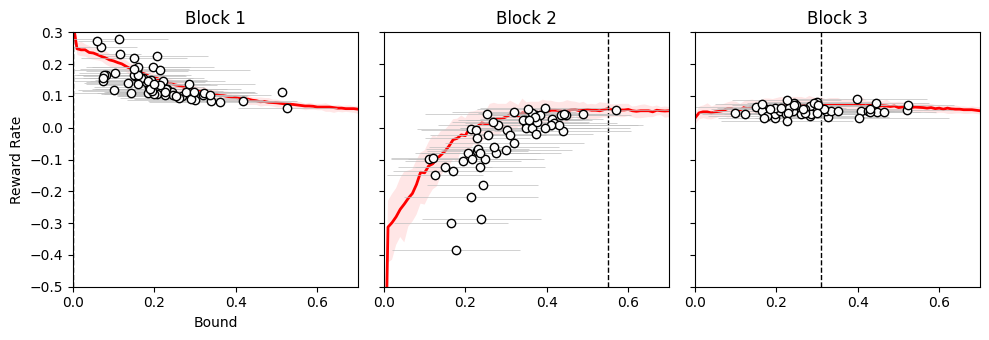

In [6]:
gr  = (0.75, 0.75, 0.75)  # gray for error bars
wt  = (0.99, 0.99, 0.99)  # near-white marker fill
rp  = (1.0,  0.9,  0.9)   # light pink for simulation ribbon

# Simulation parameters (matching MATLAB Figure04 defaults)
SIM_BOUNDS     = np.arange(0, 0.76, 0.01)   # 0 : 0.01 : 0.75
GENERATIVE_MEAN = 0.05                        # snrIndex=1, generativeMeans=[0.05 0.15]
NUM_SIM_SUBJ   = 100
rng = np.random.default_rng(0)               # fixed seed for reproducibility

fig, axs = plt.subplots(1, 3, figsize=(10, 3.5), sharey=True)

for bi, block in enumerate(BLOCKS):
    ax = axs[bi]

    # --- Simulation ribbon ---
    sim_bound_data = np.full((len(SIM_BOUNDS), 3), np.nan)  # [5th, 50th, 95th pctile]
    for ss, bnd in enumerate(SIM_BOUNDS):
        if ss % 10 == 0:
            print(f'Block {block}: simulating bound {ss+1}/{len(SIM_BOUNDS)}')
        sim_table = get_simulated_data_table(
            specs={'num_subjects': NUM_SIM_SUBJ, 'blocks': block},
            generative_mean=GENERATIVE_MEAN,
            bound_mean=bnd,
            rng=rng,
        )
        # Total coins per simulated subject (last row's cumulative coin_count)
        sim_coins = sim_table.groupby('subject_index')['coin_count'].last().to_numpy()
        sim_bound_data[ss] = np.percentile(sim_coins, [5, 50, 95]) / 600

    # Ribbon: shaded 5–95th percentile band + median line
    ax.fill_between(SIM_BOUNDS,
                    sim_bound_data[:, 0], sim_bound_data[:, 2],
                    color=rp, linewidth=0)
    ax.plot(SIM_BOUNDS, sim_bound_data[:, 1], '-', color='r', linewidth=2)

    # Vertical line at the bound with maximum simulated median reward rate
    best_idx = np.nanargmax(sim_bound_data[:, 1])
    ax.axvline(SIM_BOUNDS[best_idx], color='k', linestyle='--', linewidth=1)

    # --- Data points ---
    mean_bound  = bound_summary[:, bi, SNR_INDEX, 0, 0]
    std_bound   = bound_summary[:, bi, SNR_INDEX, 0, 1]
    reward_rate = coin_summary[:, bi, SNR_INDEX] / 600

    valid = np.isfinite(mean_bound) & np.isfinite(reward_rate)

    # Horizontal error bars (±1 SD of bound); no vertical error bars
    ax.errorbar(mean_bound[valid], reward_rate[valid],
                xerr=std_bound[valid], fmt='none',
                ecolor=gr, elinewidth=0.5, capsize=0)
    ax.plot(mean_bound[valid], reward_rate[valid], 'ko', markerfacecolor=wt)

    ax.set_xlim(0, 0.7)
    ax.set_ylim(-0.5, 0.3)
    ax.set_title(f'Block {block}')
    if bi == 0:
        ax.set_xlabel('Bound')
        ax.set_ylabel('Reward Rate')

plt.tight_layout()
plt.show()

## Bottom row: Bound comparisons across blocks
Block 1 vs 2, and block 2 vs 3. Each point = one subject.

Block 1 vs 2: median diff=0.08 [0.04 0.15], p=0.00, Spearman r=0.57 (p=0.000)
   RR: Spearman r=-0.44 (p=0.000)
Block 2 vs 3: median diff=-0.02 [-0.08 0.04], p=0.04, Spearman r=0.57 (p=0.000)
   RR: Spearman r=0.08 (p=0.563)


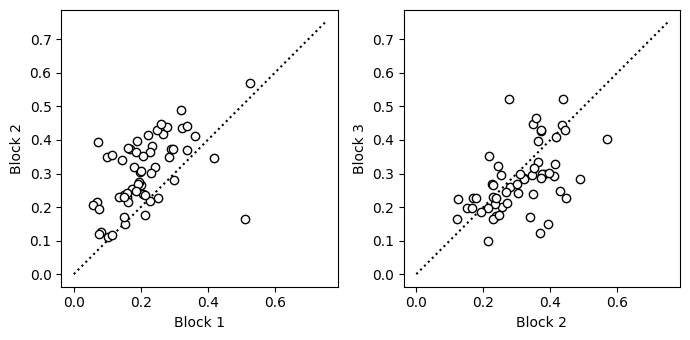

In [7]:
comparisons = [(0, 1, 1, 2), (1, 2, 2, 3)]  # (bi_x, bi_y, label_x, label_y)

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))

for ax, (bx, by, lx, ly) in zip(axs, comparisons):
    xs = bound_summary[:, bx, SNR_INDEX, 0, 0]  # mean bound, block lx
    ys = bound_summary[:, by, SNR_INDEX, 0, 0]  # mean bound, block ly

    valid = np.isfinite(xs) & np.isfinite(ys)

    # Identity line
    ax.plot([0, 0.75], [0, 0.75], 'k:')

    # One point per subject
    ax.plot(xs[valid], ys[valid], 'ko', markerfacecolor=wt)

    ax.set_xlabel(f'Block {lx}')
    ax.set_ylabel(f'Block {ly}')

    # Stats: median diff with IQR, Wilcoxon signed-rank, Spearman correlation
    diff = ys[valid] - xs[valid]
    pcts = np.percentile(diff, [25, 50, 75])
    _, p_rank = scipy.stats.wilcoxon(xs[valid], ys[valid])
    r, p_corr = scipy.stats.spearmanr(xs[valid], ys[valid])
    print(f'Block {lx} vs {ly}: median diff={pcts[1]:.2f} [{pcts[0]:.2f} {pcts[2]:.2f}], '
          f'p={p_rank:.2f}, Spearman r={r:.2f} (p={p_corr:.3f})')

    # RR correlation
    xrs = coin_summary[:, bx, SNR_INDEX][valid] / 600
    yrs = coin_summary[:, by, SNR_INDEX][valid] / 600
    rr, pr = scipy.stats.spearmanr(xrs, yrs)
    print(f'   RR: Spearman r={rr:.2f} (p={pr:.3f})')

plt.tight_layout()
plt.show()

## Formatted figure

Reproduces the 2-row × 3-column figure at publication dimensions matching MATLAB's `getPLOT_axes` call:

```matlab
getPLOT_axes(4, 17.6, [6,4], {3,3}, 1.8, 0.5, [], 'Pigeons', true)
```

- **Width**: 17.6 cm (2 JNeurosci columns)
- **Row heights**: [6, 4] cm; vertical separation 1.8 cm; horizontal 0.5 cm
- **Font size**: 12 pt
- Top row: RR vs. bound per block with simulation ribbon. Bottom row: bound comparisons (block 1 vs 2, block 2 vs 3); 6th panel left blank, matching MATLAB `set(axs(end), 'Visible', 'off')`.
- Saves to `Figure04_formatted.pdf`.

Recomputes the simulation ribbon with a fixed seed (`np.random.default_rng(0)`) for reproducibility.

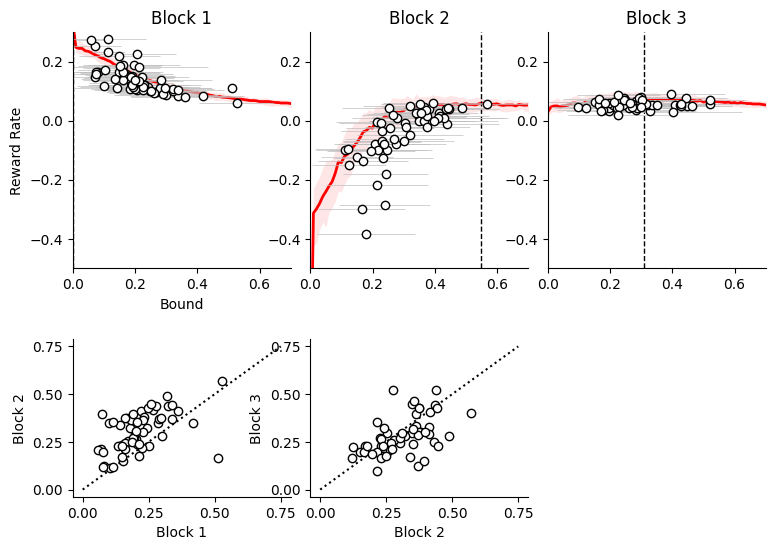

Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Figures/Figure04_formatted.pdf


In [8]:
# ── Publication layout matching MATLAB getPLOT_axes(4, 17.6, [6,4], {3,3}, 1.8, 0.5) ──
import matplotlib.gridspec as gridspec

CM  = 1 / 2.54
WID = 17.6
HTS = [6.0, 4.0]
PSH = 1.8
PSW = 0.5
FS  = 12

fig_h       = sum(HTS) + PSH * (len(HTS) - 1)   # 11.8 cm
panel_w     = (WID - 2 * PSW) / 3               # 5.533 cm
hspace_frac = PSH / np.mean(HTS)                 # 1.8 / 5
wspace_frac = PSW / panel_w                      # 0.5 / 5.533

fig_fmt = plt.figure(figsize=(WID * CM, fig_h * CM))
gs = gridspec.GridSpec(2, 3, figure=fig_fmt,
                       height_ratios=HTS,
                       hspace=hspace_frac, wspace=wspace_frac,
                       left=0, right=1, bottom=0, top=1)

axs_top = [fig_fmt.add_subplot(gs[0, c]) for c in range(3)]
axs_bot = [fig_fmt.add_subplot(gs[1, c]) for c in range(2)]  # 3rd panel left blank

plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})

gr_fmt = (0.75, 0.75, 0.75)
wt_fmt = (0.99, 0.99, 0.99)
rp_fmt = (1.0,  0.9,  0.9)

# ── Top row: RR vs. bound per block (recompute simulation with fixed seed) ────
rng_fmt = np.random.default_rng(0)

for bi, block in enumerate(BLOCKS):
    ax = axs_top[bi]

    # Simulation ribbon: 5th/50th/95th percentile of reward rate vs. bound
    sbd = np.full((len(SIM_BOUNDS), 3), np.nan)
    for ss, bnd in enumerate(SIM_BOUNDS):
        sim_table = get_simulated_data_table(
            specs={'num_subjects': NUM_SIM_SUBJ, 'blocks': block},
            generative_mean=GENERATIVE_MEAN,
            bound_mean=bnd,
            rng=rng_fmt,
        )
        sim_coins = sim_table.groupby('subject_index')['coin_count'].last().to_numpy()
        sbd[ss] = np.percentile(sim_coins, [5, 50, 95]) / 600

    ax.fill_between(SIM_BOUNDS, sbd[:, 0], sbd[:, 2], color=rp_fmt, linewidth=0)
    ax.plot(SIM_BOUNDS, sbd[:, 1], '-', color='r', linewidth=2)
    best_idx = np.nanargmax(sbd[:, 1])
    ax.axvline(SIM_BOUNDS[best_idx], color='k', linestyle='--', linewidth=1)

    # Data: mean bound ± 1 SD (horizontal error bars), reward rate on y
    mean_b   = bound_summary[:, bi, SNR_INDEX, 0, 0]
    std_b    = bound_summary[:, bi, SNR_INDEX, 0, 1]
    rr       = coin_summary[:, bi, SNR_INDEX] / 600
    valid_bi = np.isfinite(mean_b) & np.isfinite(rr)

    ax.errorbar(mean_b[valid_bi], rr[valid_bi],
                xerr=std_b[valid_bi], fmt='none',
                ecolor=gr_fmt, elinewidth=0.5, capsize=0)
    ax.plot(mean_b[valid_bi], rr[valid_bi], 'ko', markerfacecolor=wt_fmt)

    ax.set_xlim(0, 0.7)
    ax.set_ylim(-0.5, 0.3)
    ax.set_title(f'Block {block}')
    if bi == 0:
        ax.set_xlabel('Bound')
        ax.set_ylabel('Reward Rate')

# ── Bottom row: Bound comparisons across blocks ───────────────────────────────
comparisons = [(0, 1, 1, 2), (1, 2, 2, 3)]
for ax, (bx, by, lx, ly) in zip(axs_bot, comparisons):
    xs = bound_summary[:, bx, SNR_INDEX, 0, 0]
    ys = bound_summary[:, by, SNR_INDEX, 0, 0]
    valid_cc = np.isfinite(xs) & np.isfinite(ys)
    ax.plot([0, 0.75], [0, 0.75], 'k:')
    ax.plot(xs[valid_cc], ys[valid_cc], 'ko', markerfacecolor=wt_fmt)
    ax.set_xlabel(f'Block {lx}')
    ax.set_ylabel(f'Block {ly}')

for ax in axs_top + axs_bot:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

out = FIGURES_DIR / 'Figure04_formatted.pdf'
fig_fmt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out}')

## Supplemental figure: Within-block bound adaptation (OL blocks 1–3)

Two-row supplemental panel, appended to Figure 4.

**Within-block curve and its null (top row).** For each subject × block we compute a smoothed,
per-subject z-scored `abs_bound` curve over the first 40 trials (z-scoring is per subject × block,
so the curve reflects within-block adaptation relative to that participant's own block-average
bound). We repeatedly shuffle each subject's trial order *within their own block* (breaking any
time-locked structure while preserving that subject's own noise level) and recompute the same
smoothed curve, giving a null distribution specific to each subject's actual noise characteristics
with no parametric assumptions. The same 1000 shuffles, averaged across subjects within each
iteration, give a null distribution of group-mean curves; the max-stat (over all 40 trials) 95th
percentile of that null is the dashed/shaded band — corrected for the 40-timepoint
multiple-comparison problem, so a real curve poking outside the band is an above-chance,
time-locked deviation rather than noise. All three top-row panels share the same y-axis so the
panels are directly comparable.

**τ-fit eligibility criterion (bottom row).** Rather than gating every block's τ fit on the
within-block test above, blocks 2 and 3 are gated on whether there is a reliable *change from the
immediately preceding block*: a per-subject, two-sided Mann-Whitney U test on steady-state
`abs_bound` (same trial-quality filtering as `get_bound_summary`, i.e. the same quantity compared
in the block 1-vs-2 / 2-vs-3 scatter plots earlier in this notebook) between block[i-1] and
block[i]. Block 1 has no preceding block, so it keeps the within-block test as its only option.
These two criteria can disagree — a subject can shift reliably between blocks without that shift
resolving into a clean within-block exponential settle (or vice versa) — so a second filter still
applies: fits that hit the `tau_max` boundary (no resolvable decay within the 40-trial window,
e.g. slow drift) are excluded from the box/IQR and shown instead as open triangles, since their τ
is a lower bound, not a measurement.

**Top row** (one panel per block): Mean ± SEM ribbon of the smoothed z-scored curve, with the
permutation null band overlaid. Panel titles report within-block significant-adapter counts.

**Bottom row** (one panel per block): Distribution of exponential time constants τ, restricted to
subjects eligible per the criterion described above (within-block for block 1, between-block
change for blocks 2-3). Box = median / IQR; points = individual subjects; open triangles =
censored (tau pinned at `tau_max`).

In [9]:
from scipy.optimize import curve_fit
from pigeon.data import get_good_trial_array

SUPP_MAX_TRIAL = 40
SUPP_BLOCKS    = [1, 2, 3]
SUPP_HALF_WIN  = 3
SUPP_MIN_WIN   = 3
N_PERM         = 1000
PERM_SEED      = 123
SIG_ALPHA      = 0.05
TAU_MAX        = float(SUPP_MAX_TRIAL)  # can't resolve a tau longer than the fit window itself
BETWEEN_MIN_TRIALS = 5  # min good trials per block required to run the between-block test


def _build_window_matrix(t_vals, trial_nums, half_win, min_win):
    """
    Precompute the trial-window averaging weights for one subject x block.
    These weights only depend on which raw trial numbers exist (t_vals), not on the
    bound values themselves, so the same matrix can be reused for the real curve and
    for every permutation of that subject's z values.
    """
    n_bins = len(trial_nums)
    W = np.zeros((n_bins, len(t_vals)))
    valid = np.zeros(n_bins, dtype=bool)
    for ti, t in enumerate(trial_nums):
        mask = (t_vals >= t - half_win) & (t_vals <= t + half_win)
        cnt = mask.sum()
        if cnt >= min_win:
            W[ti, mask] = 1.0 / cnt
            valid[ti] = True
    return W, valid


def _exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C


def fit_exp_tau(trial_nums, z_vals, min_valid=8, tau_max=TAU_MAX):
    """
    Fit A*exp(-t/tau)+C. Returns (tau, censored):
      tau      -- fitted time constant, or NaN on failure / insufficient data
      censored -- True if the fit hit the tau_max boundary, i.e. the optimizer found
                  no resolvable decay within the fit window (slow drift, not a fast
                  settle) -- these tau values describe a lower bound, not a measurement.
    """
    valid = np.isfinite(z_vals)
    if valid.sum() < min_valid:
        return np.nan, False
    t = trial_nums[valid].astype(float)
    y = z_vals[valid]
    A0  = float(y[0] - np.nanmedian(y[-5:]))
    C0  = float(np.nanmedian(y[-5:]))
    try:
        popt, _ = curve_fit(
            _exp_decay, t, y,
            p0=[A0, 10.0, C0],
            bounds=([-np.inf, 0.5, -np.inf], [np.inf, tau_max, np.inf]),
            maxfev=5000,
        )
        tau = float(popt[1])
        return tau, tau >= tau_max - 1e-6
    except Exception:
        return np.nan, False


def compute_per_subject_curves_with_nulls(data_table, max_trial, blocks,
                                           half_win=SUPP_HALF_WIN, min_win=SUPP_MIN_WIN,
                                           n_perm=N_PERM, seed=PERM_SEED):
    """
    For every subject x block, computes the real smoothed z-scored bound curve plus
    a bank of permutation-null curves (trial order shuffled within that subject's own
    block, so each null preserves the subject's own noise level but has no time-locked
    structure). The same null bank is used downstream both for per-subject significance
    testing and for the group-level null band.

    Returns
    -------
    trial_nums  : (max_trial,) int array
    real_curves : (n_subjects, max_trial, n_blocks)
    perm_curves : (n_perm, n_subjects, max_trial, n_blocks)
    subjects    : list of subject indices
    """
    subjects   = sorted(data_table['subject_index'].dropna().unique())
    trial_nums = np.arange(1, max_trial + 1)
    rng = np.random.default_rng(seed)

    real_curves = np.full((len(subjects), max_trial, len(blocks)), np.nan)
    perm_curves = np.full((n_perm, len(subjects), max_trial, len(blocks)), np.nan)

    for bi, block in enumerate(blocks):
        lg = get_good_trial_array(
            data_table, min_dt=1, min_trial_number=None, block_index=block)
        block_data = data_table[lg]

        for si, subj in enumerate(subjects):
            sd = block_data[block_data['subject_index'] == subj]
            if sd['abs_bound'].dropna().shape[0] < 2:
                continue
            mu    = sd['abs_bound'].mean()
            sigma = sd['abs_bound'].std()
            if sigma < 1e-10:
                continue
            z      = (sd['abs_bound'].values - mu) / sigma
            t_vals = sd['trial_number'].values

            W, valid = _build_window_matrix(t_vals, trial_nums, half_win, min_win)

            curve = W @ z
            curve[~valid] = np.nan
            real_curves[si, :, bi] = curve

            z_tiled = np.broadcast_to(z, (n_perm, len(z))).copy()
            z_shuf  = rng.permuted(z_tiled, axis=1)
            perm    = z_shuf @ W.T
            perm[:, ~valid] = np.nan
            perm_curves[:, si, :, bi] = perm

    return trial_nums, real_curves, perm_curves, subjects


def per_subject_significance(real_curves, perm_curves, alpha=SIG_ALPHA):
    """
    Permutation test: does the real smoothed curve deviate from zero more than expected
    by chance? Test statistic = sum of squared curve values across the 40-trial window.
    Returns p-values and a boolean significance mask, shape (n_subjects, n_blocks).
    """
    has_data  = np.any(np.isfinite(real_curves), axis=1)
    obs_stat  = np.nansum(real_curves ** 2, axis=1)
    perm_stat = np.nansum(perm_curves ** 2, axis=2)
    counts    = np.sum(perm_stat >= obs_stat[None, :, :], axis=0)
    pvals     = (1 + counts) / (1 + perm_stat.shape[0])
    pvals     = np.where(has_data, pvals, np.nan)
    sig       = pvals < alpha
    return pvals, sig


def group_null_band(perm_curves, alpha=SIG_ALPHA):
    """
    Max-stat (Tmax) permutation threshold for the group-mean curve: average the null
    curves across subjects within each permutation iteration, take the max absolute
    deviation over all trials in that iteration, then take the alpha-level percentile
    across iterations. This single threshold is corrected for the multiple-comparison
    problem across the 40 trial timepoints.
    Returns threshold per block, shape (n_blocks,).
    """
    group_null = np.nanmean(perm_curves, axis=1)        # (n_perm, max_trial, n_blocks)
    max_stat   = np.nanmax(np.abs(group_null), axis=1)  # (n_perm, n_blocks)
    return np.percentile(max_stat, 100 * (1 - alpha), axis=0)


def between_block_significance(data_table, blocks, alpha=SIG_ALPHA,
                                min_trials=BETWEEN_MIN_TRIALS):
    """
    Per-subject test of whether steady-state |bound| differs between block[i-1] and
    block[i] (i = 1 .. len(blocks)-1). Uses the same default trial-quality filtering as
    get_bound_summary (DT>=2, trial_number>=10, wall_hit and rt_below_cutoff excluded) --
    i.e. this is the same steady-state bound quantity compared in the block-vs-block
    scatter plots earlier in this notebook, but tested per subject with an unpaired,
    two-sided Mann-Whitney U test (no normality assumption) instead of only at the
    group level.

    Returns
    -------
    pvals : (n_subjects, n_blocks) -- column 0 is NaN (no preceding block to compare)
    sig   : (n_subjects, n_blocks) bool -- column 0 is always False
    """
    subjects   = sorted(data_table['subject_index'].dropna().unique())
    n_subjects = len(subjects)
    n_blocks   = len(blocks)
    pvals = np.full((n_subjects, n_blocks), np.nan)
    sig   = np.zeros((n_subjects, n_blocks), dtype=bool)

    lg_by_block = {block: get_good_trial_array(data_table, block_index=block) for block in blocks}

    for bi in range(1, n_blocks):
        lg_prev = lg_by_block[blocks[bi - 1]]
        lg_cur  = lg_by_block[blocks[bi]]

        for si, subj in enumerate(subjects):
            subj_mask = data_table['subject_index'] == subj
            x_prev = data_table.loc[subj_mask & lg_prev, 'abs_bound'].dropna().to_numpy()
            x_cur  = data_table.loc[subj_mask & lg_cur,  'abs_bound'].dropna().to_numpy()
            if len(x_prev) < min_trials or len(x_cur) < min_trials:
                continue
            try:
                _, p = scipy.stats.mannwhitneyu(x_prev, x_cur, alternative='two-sided')
            except ValueError:
                continue
            pvals[si, bi] = p
            sig[si, bi]   = p < alpha

    return pvals, sig

In [10]:
# Load OL data retaining all 6 raw blocks so block_index matches Figure 8
data_table_ol_blocks = get_data_table(task_type='OL', combine_snr=False)

supp_trial_nums, supp_real, supp_perm, supp_subjects = compute_per_subject_curves_with_nulls(
    data_table_ol_blocks, SUPP_MAX_TRIAL, SUPP_BLOCKS)

# Group mean ± SEM for ribbon plots (all subjects, for display)
_n_valid       = np.sum(np.isfinite(supp_real), axis=0)
supp_mean      = np.nanmean(supp_real, axis=0)
supp_sem       = np.nanstd(supp_real, axis=0) / np.sqrt(np.maximum(_n_valid, 1))
supp_sem[_n_valid < 2] = np.nan

# Permutation-based group null band (max-stat corrected across the 40 trials) -- this
# and the within-block significance test below still describe the *within-block* curve
# shown in the top row, independent of which criterion gates the tau fits below.
supp_null_thresh = group_null_band(supp_perm)
supp_pvals, supp_sig = per_subject_significance(supp_real, supp_perm)

# Between-block significance: for blocks 2 and 3, does this subject's steady-state
# |bound| reliably differ from the immediately preceding block? (block 1 has no
# preceding block, so this is undefined there -- column 0 is all False/NaN.)
supp_between_pvals, supp_sig_between = between_block_significance(
    data_table_ol_blocks, SUPP_BLOCKS)

# Tau-fit eligibility: block 1 uses the within-block adaptation test (no alternative
# exists); blocks 2 and 3 use the between-block change test instead.
supp_sig_tau = supp_sig.copy()
supp_sig_tau[:, 1:] = supp_sig_between[:, 1:]

# Per-subject exponential fits -- only for subjects classified as eligible above.
# `censored` flags fits that hit tau_max: a real (eligible) deviation that isn't well
# described by a fast exponential settle within the 40-trial window (e.g. slow drift) --
# these are excluded from the tau summary/plot rather than silently padding it at the cap.
supp_taus     = np.full((len(supp_subjects), len(SUPP_BLOCKS)), np.nan)
supp_censored = np.zeros((len(supp_subjects), len(SUPP_BLOCKS)), dtype=bool)
for bi in range(len(SUPP_BLOCKS)):
    for si in range(len(supp_subjects)):
        if supp_sig_tau[si, bi]:
            tau, censored = fit_exp_tau(supp_trial_nums, supp_real[si, :, bi])
            supp_taus[si, bi]     = tau
            supp_censored[si, bi] = censored

print('Per-block adaptation summary:')
for bi, block in enumerate(SUPP_BLOCKS):
    n_total   = np.sum(np.any(np.isfinite(supp_real[:, :, bi]), axis=1))
    n_within  = np.sum(supp_sig[:, bi])
    mean_curve = supp_mean[:, bi]
    max_abs   = np.nanmax(np.abs(mean_curve))
    exceeds   = max_abs > supp_null_thresh[bi]
    print(f'  Block {block}: {n_within}/{n_total} subjects show within-block adaptation '
          f'({100 * n_within / max(n_total, 1):.0f}%)')
    print(f'    group mean curve: max|curve|={max_abs:.3f} vs. null threshold '
          f'±{supp_null_thresh[bi]:.3f} -> {"exceeds null" if exceeds else "within null"}')

    if bi == 0:
        n_qual, crit_label = n_within, 'within-block adaptation (no preceding block)'
    else:
        n_qual = np.sum(supp_sig_between[:, bi])
        crit_label = f'significant change vs. block {SUPP_BLOCKS[bi - 1]} (Mann-Whitney U)'
    print(f'    tau-fit eligibility: {n_qual}/{n_total} subjects qualify ({crit_label})')

    is_censored = supp_censored[:, bi]
    vt = supp_taus[:, bi][np.isfinite(supp_taus[:, bi]) & ~is_censored]
    n_cens = np.sum(is_censored)
    if len(vt):
        q25, med, q75 = np.percentile(vt, [25, 50, 75])
        print(f'    τ (eligible, non-censored): median={med:.1f}  '
              f'IQR=[{q25:.1f}, {q75:.1f}]  n={len(vt)}  '
              f'(+{n_cens} censored at tau_max, excluded)')
    else:
        print(f'    τ: no uncensored fits ({n_cens} eligible subjects censored at tau_max)')

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

 14: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_17h35.53.048.csv
 15: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_17h48.56.013.csv
 16: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_19h38.38.956.csv
 17: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h36.04.663.csv
 18: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h36.05.544.csv
 19: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h36.07.852.csv
 20: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h37.13.084.csv
 21: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

 28: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h40.06.581.csv
 29: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h41.15.620.csv
 30: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h42.16.563.csv
 31: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h46.46.975.csv
 32: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_22h54.23.759.csv
 33: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_23h30.52.958.csv
 34: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_23h34.58.360.csv
 35: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

 42: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_23h38.40.851.csv
 43: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_23h39.13.059.csv
 44: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_23h41.40.441.csv
 45: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_23h42.52.039.csv
 46: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_23h42.54.723.csv
 47: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_23h49.12.728.csv
 48: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-22_01h07.36.399.csv
 49: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

 55: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-22_24h37.37.464.csv
 56: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-22_24h38.28.207.csv
 57: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-22_24h39.12.114.csv
 58: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-22_24h40.02.817.csv
 59: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-22_24h40.07.382.csv
 60: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-22_24h41.01.524.csv


Per-block adaptation summary:
  Block 1: 18/58 subjects show within-block adaptation (31%)
    group mean curve: max|curve|=0.220 vs. null threshold ±0.162 -> exceeds null
    tau-fit eligibility: 18/58 subjects qualify (within-block adaptation (no preceding block))
    τ (eligible, non-censored): median=4.8  IQR=[3.5, 8.2]  n=11  (+7 censored at tau_max, excluded)
  Block 2: 17/60 subjects show within-block adaptation (28%)
    group mean curve: max|curve|=0.362 vs. null threshold ±0.172 -> exceeds null
    tau-fit eligibility: 40/60 subjects qualify (significant change vs. block 1 (Mann-Whitney U))
    τ (eligible, non-censored): median=8.7  IQR=[5.5, 15.4]  n=25  (+15 censored at tau_max, excluded)
  Block 3: 14/59 subjects show within-block adaptation (24%)
    group mean curve: max|curve|=0.169 vs. null threshold ±0.173 -> within null
    tau-fit eligibility: 18/59 subjects qualify (significant change vs. block 2 (Mann-Whitney U))
    τ (eligible, non-censored): median=3.3  IQR=[2

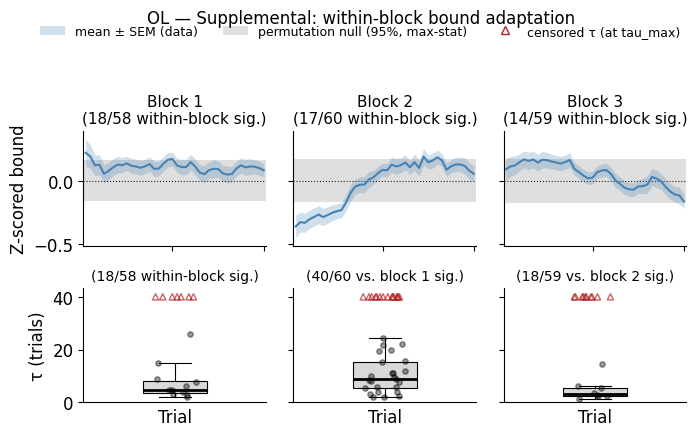

Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Figures/Figure04_supplement_learning.pdf


In [11]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

_CM    = 1 / 2.54
_WID   = 17.6
_HTS   = [4.0, 4.0]
_PSH   = 1.5
_PSW   = 0.8
_FS    = 12
_COLOR = 'steelblue'
_NULL_COLOR = (0.5, 0.5, 0.5)

_fig_h   = sum(_HTS) + _PSH + 1.6  # headroom for two-line block titles + suptitle/legend
_panel_w = (_WID - 2 * _PSW) / 3

plt.rcParams.update({'font.size': _FS, 'axes.labelsize': _FS, 'axes.titlesize': _FS})

fig_supp = plt.figure(figsize=(_WID * _CM, _fig_h * _CM))
gs_supp  = gridspec.GridSpec(
    2, 3, figure=fig_supp,
    height_ratios=_HTS,
    hspace=_PSH / np.mean(_HTS),
    wspace=_PSW / _panel_w,
    left=0.10, right=0.97, bottom=0.10, top=0.72,
)

# Shared y-limits for the top row, so the three panels are directly comparable rather
# than each being independently autoscaled (which made the noise in blocks 1 and 3 look
# similar in size to the real effect in block 2 purely because of differing y-ranges).
_top_lo = min(np.nanmin(supp_mean - supp_sem), -np.max(supp_null_thresh))
_top_hi = max(np.nanmax(supp_mean + supp_sem), np.max(supp_null_thresh))
_top_pad = 0.08 * (_top_hi - _top_lo)
TOP_YLIM = (_top_lo - _top_pad, _top_hi + _top_pad)

# ── Row 1: mean ± SEM learning curves, with permutation null band ────────────
for bi, block in enumerate(SUPP_BLOCKS):
    ax  = fig_supp.add_subplot(gs_supp[0, bi])
    mn  = supp_mean[:, bi]
    sem = supp_sem[:, bi]
    ok  = np.isfinite(mn) & np.isfinite(sem)
    thr = supp_null_thresh[bi]

    ax.axhline(0, color='k', linestyle=':', linewidth=0.8, zorder=0)
    ax.axhspan(-thr, thr, color=_NULL_COLOR, alpha=0.25, linewidth=0, zorder=0)
    ax.fill_between(supp_trial_nums[ok], mn[ok] - sem[ok], mn[ok] + sem[ok],
                    alpha=0.25, color=_COLOR, linewidth=0)
    ax.plot(supp_trial_nums[ok], mn[ok], '-', color=_COLOR, linewidth=1.5)

    ax.set_xlim(0.5, SUPP_MAX_TRIAL + 0.5)
    ax.set_ylim(*TOP_YLIM)
    n_total  = np.sum(np.any(np.isfinite(supp_real[:, :, bi]), axis=1))
    n_within = np.sum(supp_sig[:, bi])
    ax.set_title(f'Block {block}\n({n_within}/{n_total} within-block sig.)', fontsize=_FS - 1)
    if bi == 0:
        ax.set_ylabel('Z-scored bound')
    else:
        ax.tick_params(axis='y', labelleft=False)
    ax.tick_params(axis='x', labelbottom=False)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

# Single figure-level legend (rather than one drawn inside a panel, which could be
# mistaken for a data feature) explaining the shaded regions and the censored marker.
_legend_handles = [
    Patch(facecolor=_COLOR, alpha=0.25, label='mean ± SEM (data)'),
    Patch(facecolor=_NULL_COLOR, alpha=0.25, label='permutation null (95%, max-stat)'),
    Line2D([], [], marker='^', linestyle='none', markerfacecolor='none',
           markeredgecolor='firebrick', label='censored τ (at tau_max)'),
]
fig_supp.legend(handles=_legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.99),
                ncol=3, frameon=False, fontsize=_FS - 3)

# ── Row 2: per-subject τ distributions ────────────────────────────────────────────────
# Block 1 is gated by the within-block adaptation test (no preceding block exists).
# Blocks 2-3 are gated by a between-block test instead (Mann-Whitney U on steady-state
# |bound|, this subject's block[i-1] vs block[i]) -- a subject can change reliably from
# one block to the next without that change being resolvable as a fast within-block
# settle, so these criteria can disagree; the title reports whichever one gated that panel.
# Within the eligible set, fits that hit the tau_max boundary (no resolvable decay within
# the 40-trial window -- e.g. slow drift) are excluded from the box/IQR and shown instead
# as open triangles at the top of the panel, since their tau is a lower bound, not a
# measurement.
_rng_jit = np.random.default_rng(42)
for bi, block in enumerate(SUPP_BLOCKS):
    ax = fig_supp.add_subplot(gs_supp[1, bi])
    is_censored = supp_censored[:, bi]
    vt   = supp_taus[:, bi][np.isfinite(supp_taus[:, bi]) & ~is_censored]
    n_cens = np.sum(is_censored)

    if len(vt):
        ax.boxplot(vt, positions=[1], widths=0.35,
                   patch_artist=True,
                   medianprops=dict(color='k', linewidth=2),
                   boxprops=dict(facecolor=(0.85, 0.85, 0.85), linewidth=0.8),
                   whiskerprops=dict(linewidth=0.8),
                   capprops=dict(linewidth=0.8),
                   flierprops=dict(marker='none'))
        jit = _rng_jit.uniform(-0.12, 0.12, len(vt))
        ax.scatter(np.ones(len(vt)) + jit, vt, s=15, color='k', alpha=0.4, zorder=4)
    else:
        ax.text(1, SUPP_MAX_TRIAL / 2, 'no uncensored\nfits', ha='center', va='center',
                fontsize=_FS - 2)

    if n_cens:
        jit_c = _rng_jit.uniform(-0.12, 0.12, n_cens)
        ax.scatter(np.ones(n_cens) + jit_c, np.full(n_cens, SUPP_MAX_TRIAL),
                   marker='^', s=20, facecolor='none', edgecolor='firebrick', alpha=0.7, zorder=5)

    n_total = np.sum(np.any(np.isfinite(supp_real[:, :, bi]), axis=1))
    if bi == 0:
        n_qual, crit_label = np.sum(supp_sig[:, bi]), 'within-block'
    else:
        n_qual = np.sum(supp_sig_between[:, bi])
        crit_label = f'vs. block {SUPP_BLOCKS[bi - 1]}'
    ax.set_title(f'({n_qual}/{n_total} {crit_label} sig.)', fontsize=_FS - 2)

    ax.set_xlim(0.5, 1.5)
    ax.set_ylim(0, SUPP_MAX_TRIAL * 1.08)
    ax.set_xticks([])
    ax.set_xlabel('Trial')
    if bi == 0:
        ax.set_ylabel('τ (trials)')
    else:
        ax.tick_params(axis='y', labelleft=False)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

fig_supp.suptitle('OL — Supplemental: within-block bound adaptation', fontsize=_FS, y=1.0)

out_supp = FIGURES_DIR / 'Figure04_supplement_learning.pdf'
fig_supp.savefig(out_supp, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out_supp}')